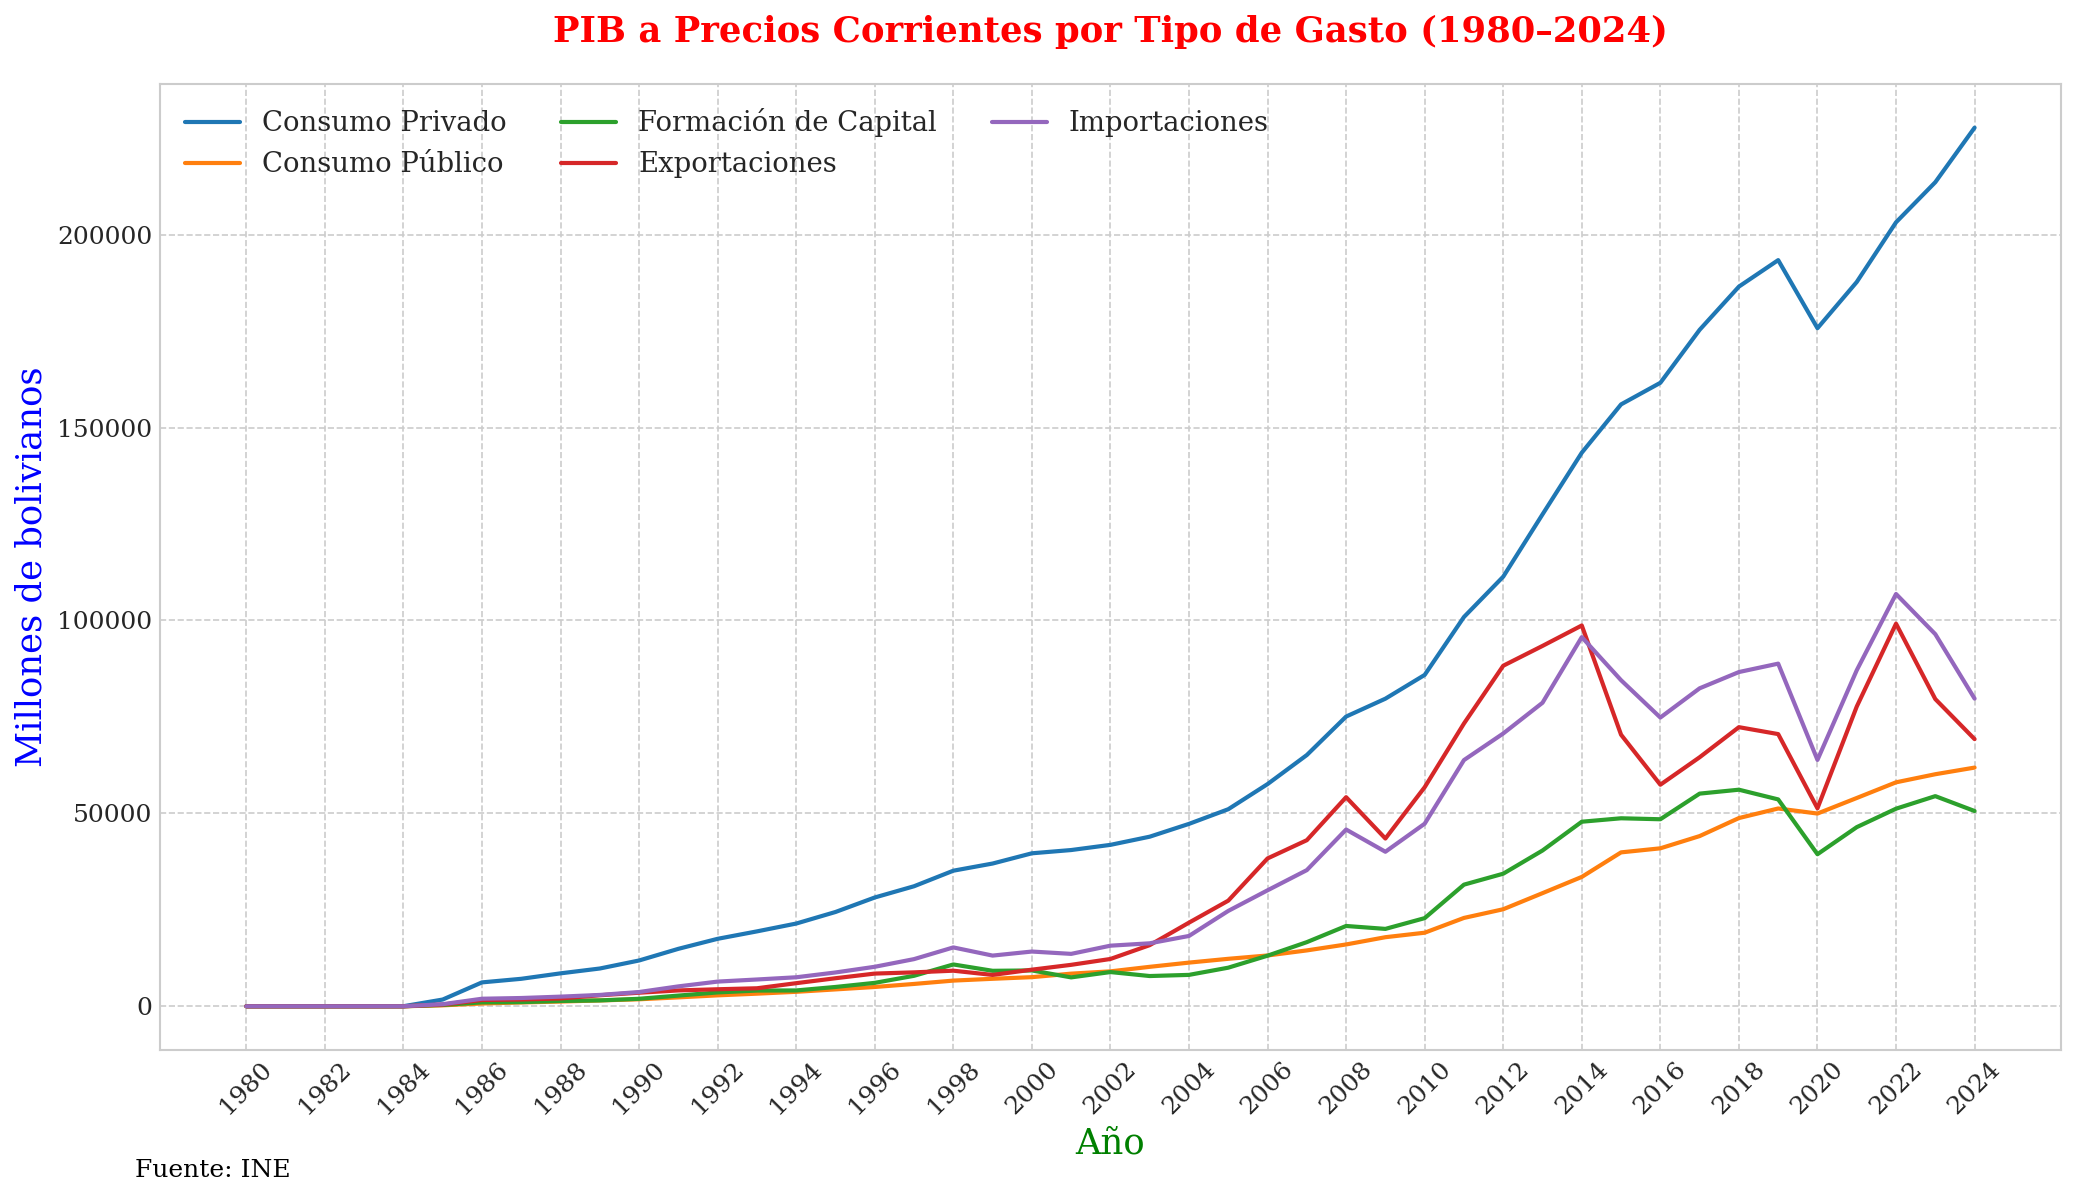

In [1]:
# ───────────────────────────── IMPORTS ──────────────────────────────
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt 

# IMPORTANTE: Importación correcta de las funciones auxiliares
from func_auxiliares.graficos_utils import (
    set_style,                          # Estilo corporativo
    init_base_plot,                     # Configuración base del gráfico
    add_hitos,                          # Líneas verticales de hitos
    add_cycle_means_multi,              # Medias por ciclo
    add_year_value_annotations,         # Anotaciones de valores por año
    add_period_growth_annotations_multi,# Tasas de crecimiento por período
    adjust_annot_years,                 # Ajustar años de anotación al DataFrame
    adjust_cycles,                      # Ajustar ciclos al DataFrame
    adjust_periods,                     # Ajustar períodos al DataFrame
)

from func_auxiliares.config import (
    DB_PATH,                            # Ruta a la base de datos
    CYCLES,                             # Diccionario de ciclos económicos
    annot_years,                        # Lista de años para anotaciones
    periodos_tasas,                     # Períodos para calcular tasas
    hitos_v,                            # Diccionario de hitos verticales
    ASSETS_DIR,
)

set_style()  # Aplica el estilo corporativo unificado
# ───────────────────────── 2. CARGA DE DATOS ────────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM pib_nominal_gasto",
            conn,
            index_col="año"
        )
        .sort_index()
    )

# Convertir miles a millones para mejor legibilidad
valor_cols = ['gastos_consumo', 'consumo_privado', 'consumo_publico', 
              'formacion_capital', 'exportacion_bienes_servicios', 
              'importacion_bienes', 'pib_a_precios_corrientes']
df[valor_cols] = df[valor_cols] / 1000  # Miles a millones
df.head()
# ──────────────── 3. COMPONENTES Y PREPARACIÓN ──────────────────────
# Definir las series a graficar (tuplas de columna_df, etiqueta_display)
componentes = [
    ("consumo_privado", "Consumo Privado"),
    ("consumo_publico", "Consumo Público"),
    ("formacion_capital", "Formación de Capital"),
    ("exportacion_bienes_servicios", "Exportaciones"),
    ("importacion_bienes", "Importaciones"),
]

# Extraer solo los nombres de columnas
cols_componentes = [col for col, _ in componentes]

# Definir colores para cada serie
colors = {
    "consumo_privado": "#1f77b4",               # Azul
    "consumo_publico": "#ff7f0e",               # Naranja
    "formacion_capital": "#2ca02c",             # Verde
    "exportacion_bienes_servicios": "#d62728",  # Rojo
    "importacion_bienes": "#9467bd",            # Púrpura
}
# ────────────────────────── 6. GRÁFICO BASE ──────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,           # Lista de tuplas (columna, etiqueta)
    colors=colors,                # Diccionario de colores
    title=f"PIB a Precios Corrientes por Tipo de Gasto ({df.index.min()}–{df.index.max()})",
    xlabel="Año",
    ylabel="Millones de bolivianos",
    source_text="Fuente: INE",
    figsize=(14, 8),             # Tamaño de figura
    legend_loc="upper left"       # Ubicación de leyenda
)
plt.show()


# Comparación: Método Anterior vs Método Mejorado para Plotter

El **Generador de Gráficas** ahora usa la misma lógica que los notebooks de serie completa.

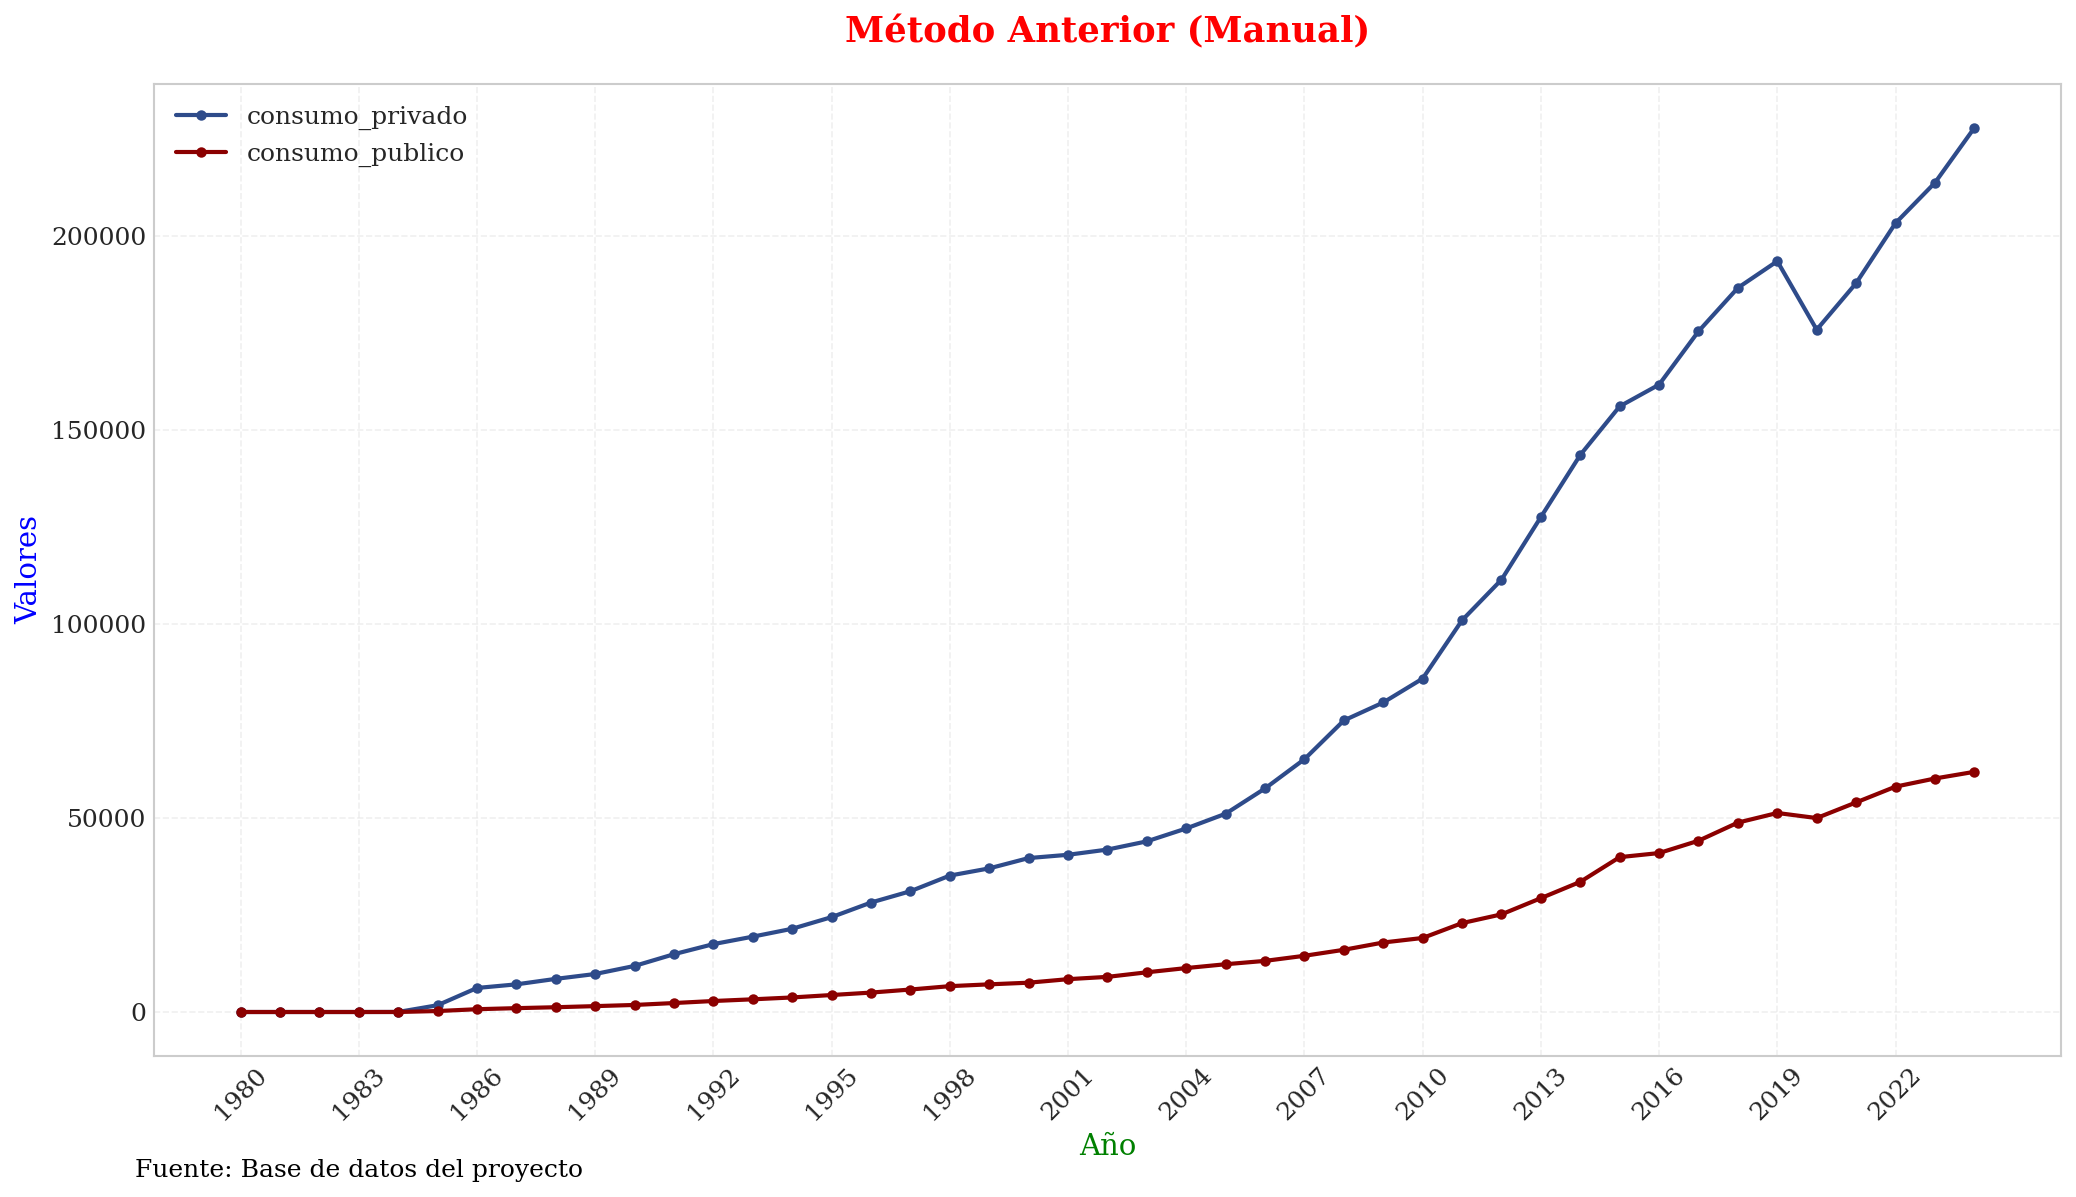

In [2]:
# ========================================================
# MÉTODO ANTERIOR (MANUAL) - Como estaba en plotter_matplotlib.py
# ========================================================

def create_simple_lineplot_old(df, columns, title="Gráfica Manual"):
    """Método anterior: creación manual de la gráfica"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Colores básicos
    colors = ['#2E4B8A', '#8B0000', '#228B22', '#FF8C00', '#9932CC']
    
    # Dibujar líneas manualmente
    for i, col in enumerate(columns):
        if col in df.columns:
            color = colors[i % len(colors)]
            ax.plot(df.index, df[col], label=col, color=color, linewidth=2, marker='o', markersize=4)
    
    # Configuración manual
    ax.set_title(title, fontweight='bold', color='red', fontsize=17, pad=20)
    ax.set_xlabel("Año", color='green', fontsize=14)
    ax.set_ylabel("Valores", color='blue', fontsize=14)
    ax.set_xticks(df.index[::max(1, len(df)//15)])
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    if len(columns) > 1:
        ax.legend(loc='upper left', fontsize=12, frameon=False)
    
    fig.text(0.07, 0.005, "Fuente: Base de datos del proyecto",
             ha="left", va="bottom", fontsize=12, color="black",
             transform=fig.transFigure)
    
    plt.tight_layout()
    return fig

# Probar método anterior
fig_old = create_simple_lineplot_old(df, ["consumo_privado", "consumo_publico"], 
                                     "Método Anterior (Manual)")
plt.show()

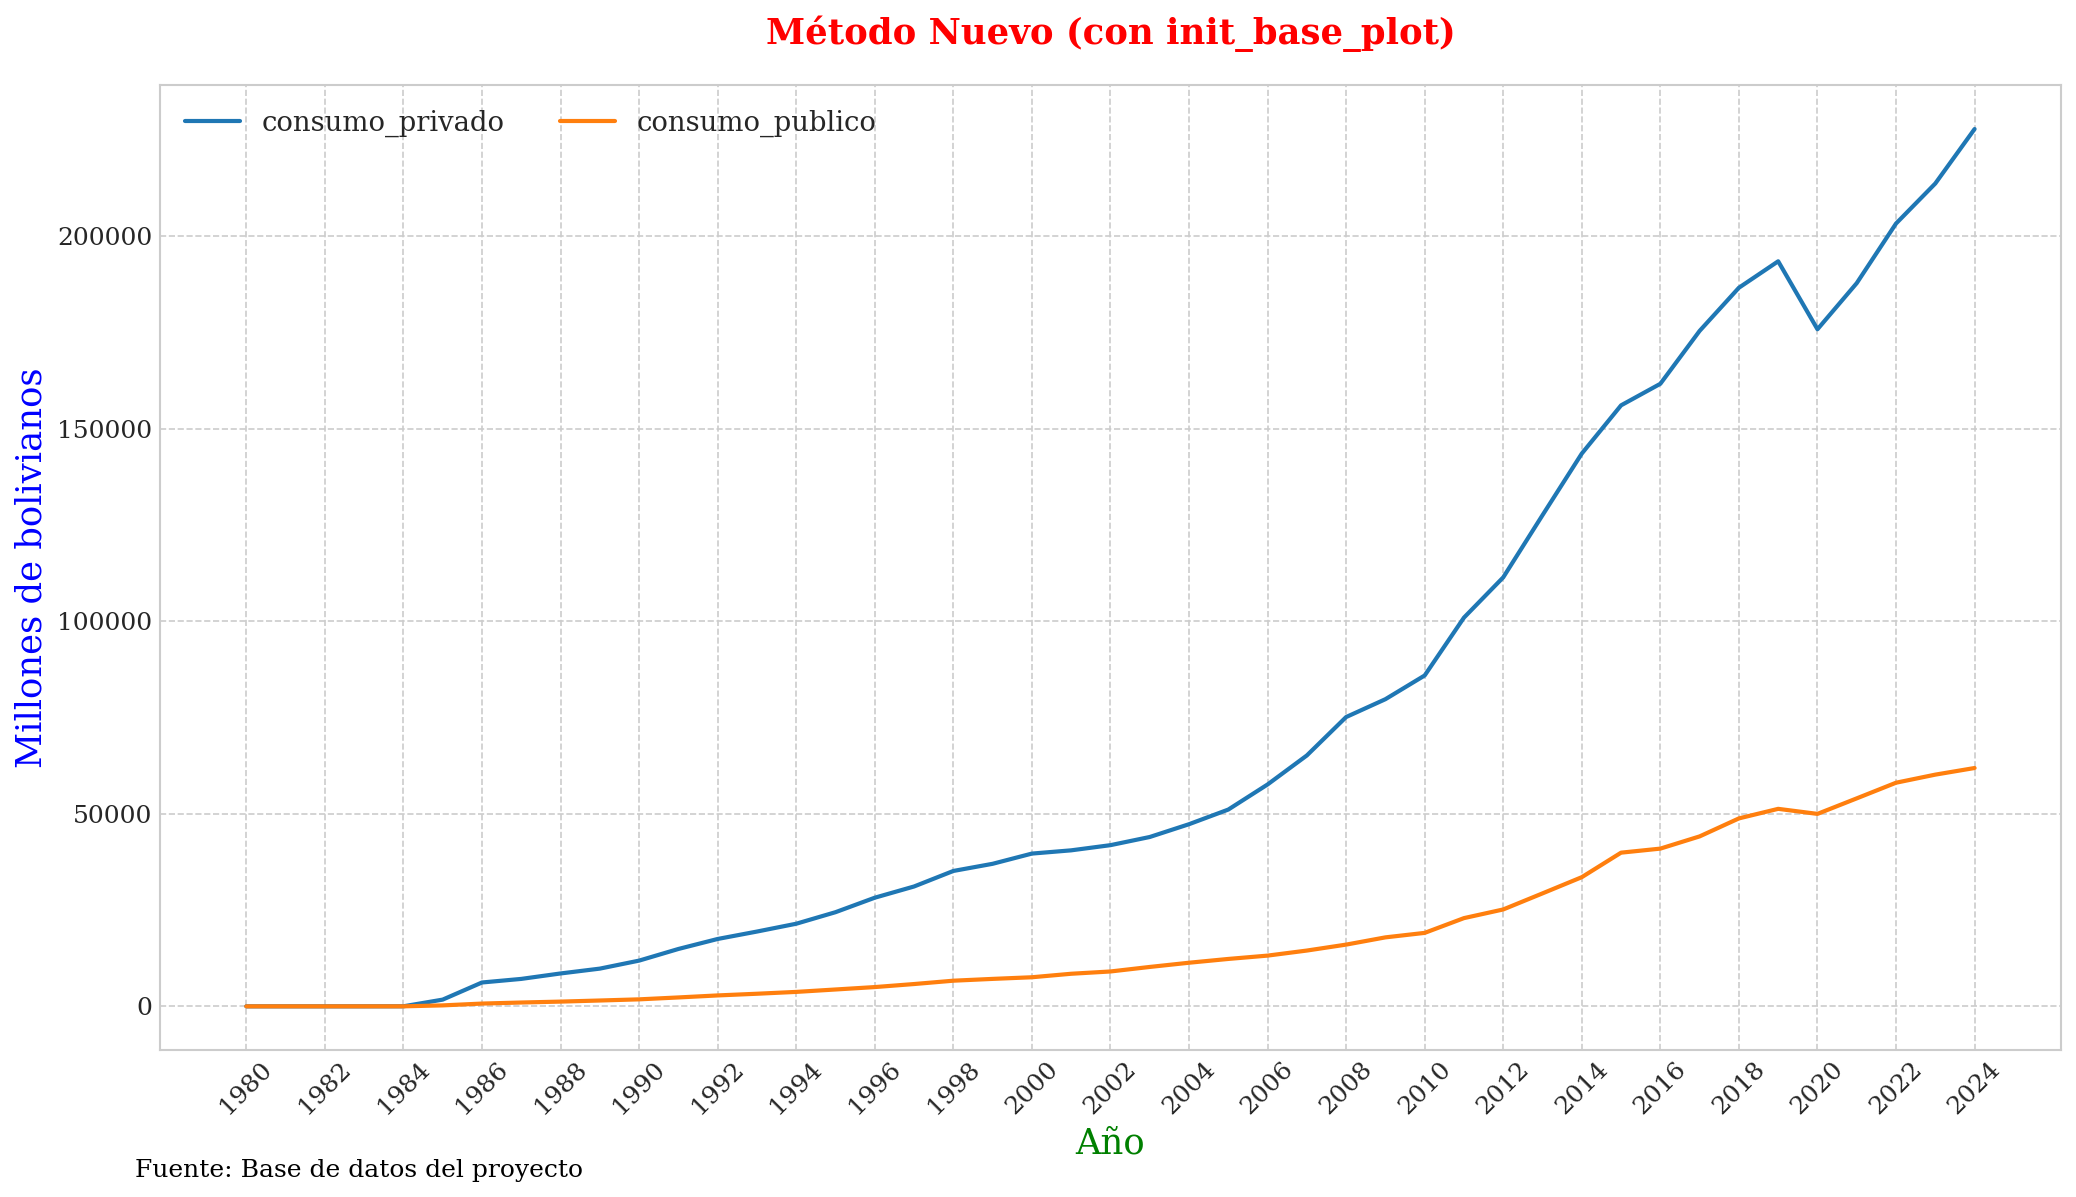

In [3]:
# ========================================================
# MÉTODO NUEVO (CON INIT_BASE_PLOT) - Como está ahora en plotter_matplotlib.py
# ========================================================

def create_simple_lineplot_new(df, columns, title="Gráfica con init_base_plot"):
    """
    Método nuevo: usa init_base_plot como en notebooks de serie completa
    Sin anotaciones, medias, tasas, ni elementos adicionales
    """
    set_style()  # Aplicar estilo corporativo
    
    # Preparar componentes como en los notebooks
    componentes = [(col, col) for col in columns if col in df.columns]
    
    # Definir colores corporativos
    available_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    colors = {}
    for i, col in enumerate(columns):
        if col in df.columns:
            colors[col] = available_colors[i % len(available_colors)]
    
    # Usar init_base_plot exactamente como en los notebooks
    fig, ax = init_base_plot(
        df=df,
        series=componentes,           # Lista de tuplas (columna, etiqueta)
        colors=colors,                # Diccionario de colores
        title=title,
        xlabel="Año",
        ylabel="Millones de bolivianos",
        source_text="Fuente: Base de datos del proyecto",
        figsize=(14, 8),             # Tamaño de figura
        legend_loc="upper left"       # Ubicación de leyenda
    )
    
    plt.tight_layout()
    return fig

# Probar método nuevo - MISMO RESULTADO que los notebooks de serie completa
fig_new = create_simple_lineplot_new(df, ["consumo_privado", "consumo_publico"], 
                                     "Método Nuevo (con init_base_plot)")
plt.show()

## Ventajas del Método Nuevo

### ✅ **Consistencia Visual**
- **Mismo estilo** que todos los notebooks de serie completa
- **Colores corporativos** aplicados consistentemente
- **Tipografía y formato** unificados

### ✅ **Mantenibilidad del Código**
- **Una sola función** (`init_base_plot`) para todas las gráficas base
- **Cambios centralizados** en `func_auxiliares/graficos_utils.py`
- **Menos duplicación** de código

### ✅ **Funcionalidad Robusta**
- **Manejo automático** de estilos y configuraciones
- **Configuración flexible** de parámetros (tamaño, colores, leyenda)
- **Compatibilidad total** con el sistema existente

### 🎯 **Resultado**
El **Generador de Gráficas** ahora produce exactamente el mismo tipo de visualizaciones que los notebooks de serie completa, pero sin los elementos adicionales (anotaciones, medias, tasas, etc.).